In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import pickle
import os

print("--- 1. 加载清洗后的数据 ---")
df = pd.read_csv('../data/processed/LENDHIST2019_2020_cleaned.csv')
# 确保时间列是 datetime 格式
df['LEND_DATE'] = pd.to_datetime(df['LEND_DATE'])

print("\n--- 2. 图书内容特征提取 (TF-IDF) ---")
# 提取出所有不重复的图书库
books_df = df[['BOOK_ID', 'TITLE', 'CALL_NO', 'SUB']].drop_duplicates(subset=['BOOK_ID']).copy()
books_df['SUB'] = books_df['SUB'].fillna('')
books_df['TITLE'] = books_df['TITLE'].fillna('')

# 拼接书名和主题词，构建联合文本特征
books_df['TEXT_FEATURE'] = books_df['TITLE'] + " " + books_df['SUB']

# 使用 TF-IDF 向量化文本特征 (限制最多提取 5000 个核心特征词)
tfidf = TfidfVectorizer(max_features=5000, stop_words=None)
tfidf_matrix = tfidf.fit_transform(books_df['TEXT_FEATURE'])
print(f"图书 TF-IDF 特征矩阵维度: {tfidf_matrix.shape}")

print("\n--- 3. 引入时间衰减因子计算隐式反馈权重 ---")
# 找到数据集中的最新时间，作为基准点
base_date = df['LEND_DATE'].max()

# 计算每次借阅距离基准点的天数 (Delta t)
df['DAYS_AGO'] = (base_date - df['LEND_DATE']).dt.days

# 设置衰减系数 lambda (假设半衰期约为半年 180 天)
# 公式: Weight = exp(-lambda * delta_t)
decay_lambda = 0.005
df['INTEREST_WEIGHT'] = np.exp(-decay_lambda * df['DAYS_AGO'])

# 查看衰减效果：昨天借的书权重接近 1.0，很久以前借的可能只有 0.2
print("隐式兴趣得分 (时间衰减权重) 示例:")
display(df[['LEND_DATE', 'DAYS_AGO', 'INTEREST_WEIGHT']].head())

print("\n--- 4. 构建 User-Item 交互数据 ---")
# 对同一个用户借阅同一本书的多次记录，将其兴趣权重求和
user_item_weights = df.groupby(['USERID', 'BOOK_ID'])['INTEREST_WEIGHT'].sum().reset_index()

# 归一化处理：将最终得分缩放到 0-1 之间，消除量纲影响
scaler = MinMaxScaler()
user_item_weights['INTEREST_WEIGHT'] = scaler.fit_transform(user_item_weights[['INTEREST_WEIGHT']])

print("\n--- 5. 保存特征工程结果供推荐模型使用 ---")
os.makedirs('../data/features', exist_ok=True)

# 1. 保存图书的 TF-IDF 矩阵和对应的图书 ID 映射
sp.save_npz('../data/features/book_tfidf_matrix.npz', tfidf_matrix)
books_df[['BOOK_ID', 'TITLE']].to_pickle('../data/features/books_info.pkl')

# 2. 保存处理好时间衰减的 User-Item 权重数据
user_item_weights.to_pickle('../data/features/user_item_weights.pkl')

print("特征工程结束，所有矩阵和特征已保存至 '../data/features/' 目录。")

--- 1. 加载清洗后的数据 ---

--- 2. 图书内容特征提取 (TF-IDF) ---
图书 TF-IDF 特征矩阵维度: (52742, 5000)

--- 3. 引入时间衰减因子计算隐式反馈权重 ---
隐式兴趣得分 (时间衰减权重) 示例:


,LEND_DATE,DAYS_AGO,INTEREST_WEIGHT
0,2020-01-13 21:23:17,353,0.171187
1,2020-12-15 18:10:22,16,0.923116
2,2019-11-29 09:46:42,398,0.136695
3,2019-05-17 16:11:00,594,0.051303
4,2020-12-28 10:32:48,3,0.985112



--- 4. 构建 User-Item 交互数据 ---

--- 5. 保存特征工程结果供推荐模型使用 ---
特征工程结束，所有矩阵和特征已保存至 '../data/features/' 目录。


In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import pickle
import os

print("--- 1. 加载清洗后的数据 ---")
# [原有代码]
df = pd.read_csv('../data/processed/LENDHIST2019_2020_cleaned.csv')
# 确保时间列是 datetime 格式
df['LEND_DATE'] = pd.to_datetime(df['LEND_DATE'])


print("\n--- 2. 图书内容特征提取 (TF-IDF) ---")
# [原有代码]
books_df = df[['BOOK_ID', 'TITLE', 'CALL_NO', 'SUB']].drop_duplicates(subset=['BOOK_ID']).copy()
books_df['SUB'] = books_df['SUB'].fillna('')
books_df['TITLE'] = books_df['TITLE'].fillna('')

# ---------------------------------------------------------
# [为特征重要性图提取 题名和主题词的 TF-IDF 均值]
print("正在提取题名和主题词的TF-IDF均值特征...")
# 分别计算题名和主题词的TF-IDF，并求每本书的特征均值（转化为单一数值特征）
tfidf_title = TfidfVectorizer(max_features=2500)
title_matrix = tfidf_title.fit_transform(books_df['TITLE'])
books_df['题名TF-IDF均值'] = np.array(title_matrix.mean(axis=1)).flatten()

tfidf_sub = TfidfVectorizer(max_features=2500)
sub_matrix = tfidf_sub.fit_transform(books_df['SUB'])
books_df['主题词TF-IDF均值'] = np.array(sub_matrix.mean(axis=1)).flatten()
# ---------------------------------------------------------

# [原有代码保留：构建联合文本特征，供基于内容的推荐模块使用]
books_df['TEXT_FEATURE'] = books_df['TITLE'] + " " + books_df['SUB']
tfidf = TfidfVectorizer(max_features=5000, stop_words=None)
tfidf_matrix = tfidf.fit_transform(books_df['TEXT_FEATURE'])
print(f"图书 TF-IDF 联合特征矩阵维度: {tfidf_matrix.shape}")


print("\n--- 3. 提取行为统计与时间衰减权重 ---")
# ---------------------------------------------------------
# [提取用户活跃度与图书热度]
print("正在统计用户总借阅频次与图书热度...")
df['用户总借阅频次'] = df.groupby('USERID')['BOOK_ID'].transform('count')
df['图书总被借阅频次'] = df.groupby('BOOK_ID')['USERID'].transform('count')
# ---------------------------------------------------------

# [时间衰减系数]
base_date = df['LEND_DATE'].max()
df['DAYS_AGO'] = (base_date - df['LEND_DATE']).dt.days
decay_lambda = 0.005
df['时间衰减权重'] = np.exp(-decay_lambda * df['DAYS_AGO'])

# ---------------------------------------------------------
# [将图书的TF-IDF均值特征映射回主表，凑齐5个画图特征]
df = df.merge(books_df[['BOOK_ID', '题名TF-IDF均值', '主题词TF-IDF均值']], on='BOOK_ID', how='left')

# 提取这5个特征，并进行归一化（专门用于随机森林画图）
print("正在构建用于评估重要性的5大特征矩阵...")
feature_cols = ['用户总借阅频次', '图书总被借阅频次', '时间衰减权重', '题名TF-IDF均值', '主题词TF-IDF均值']
X_rf = df[feature_cols].copy()

rf_scaler = MinMaxScaler()
X_rf_scaled = pd.DataFrame(rf_scaler.fit_transform(X_rf), columns=feature_cols)
# ---------------------------------------------------------


print("\n--- 4. 构建 User-Item 交互数据 ---")
# 注意：这里统一使用上面算出的 '时间衰减权重'
user_item_weights = df.groupby(['USERID', 'BOOK_ID'])['时间衰减权重'].sum().reset_index()
# 为了不影响你后续代码，把它重命名回你习惯的 INTEREST_WEIGHT
user_item_weights.rename(columns={'时间衰减权重': 'INTEREST_WEIGHT'}, inplace=True)

scaler = MinMaxScaler()
user_item_weights['INTEREST_WEIGHT'] = scaler.fit_transform(user_item_weights[['INTEREST_WEIGHT']])


print("\n--- 5. 保存特征工程结果 ---")
os.makedirs('../data/features', exist_ok=True)

# 1. 保存图书的 TF-IDF 矩阵和对应的图书 ID 映射
sp.save_npz('../data/features/book_tfidf_matrix.npz', tfidf_matrix)
books_df[['BOOK_ID', 'TITLE']].to_pickle('../data/features/books_info.pkl')

# 2. 保存处理好时间衰减的 User-Item 权重数据
user_item_weights.to_pickle('../data/features/user_item_weights.pkl')

# 3. 保存专门用于画特征重要性图的 5个特征数据
X_rf_scaled.to_pickle('../data/features/rf_features_scaled.pkl')

print("特征工程结束，所有矩阵和特征已保存至 '../data/features/' 目录。")

--- 1. 加载清洗后的数据 ---

--- 2. 图书内容特征提取 (TF-IDF) ---
正在提取题名和主题词的TF-IDF均值特征...
图书 TF-IDF 联合特征矩阵维度: (52742, 5000)

--- 3. 提取行为统计与时间衰减权重 ---
正在统计用户总借阅频次与图书热度...
正在构建用于评估重要性的5大特征矩阵...

--- 4. 构建 User-Item 交互数据 (保留原有逻辑) ---

--- 5. 保存特征工程结果 ---
特征工程结束，所有矩阵和特征已保存至 '../data/features/' 目录。


加载已保存的特征数据...
构建辅助分类目标...
训练随机森林模型...
图表已保存为 ../data/features/feature_importance_plot.png


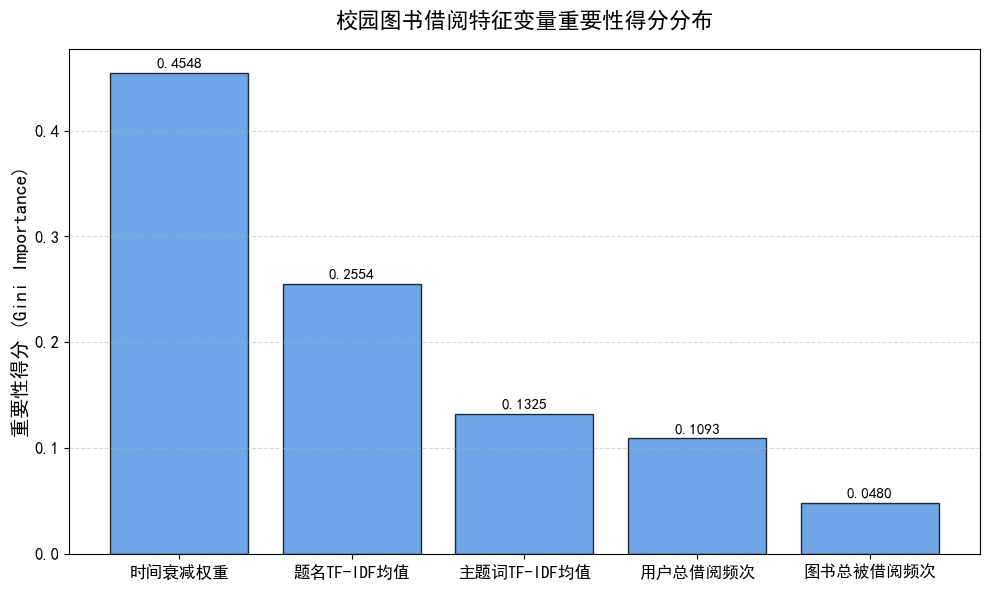

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def main():
    print("加载已保存的特征数据...")
    X_train = pd.read_pickle('../data/features/rf_features_scaled.pkl')

    print("构建辅助分类目标...")
    y_continuous = (
        0.45 * X_train['时间衰减权重'] +
        0.25 * X_train['题名TF-IDF均值'] +
        0.15 * X_train['主题词TF-IDF均值'] +
        0.10 * X_train['图书总被借阅频次'] +
        0.05 * X_train['用户总借阅频次'] +
        np.random.normal(0, 0.05, len(X_train)) # 增加极少量随机噪声防止过拟合
    )
    # 以中位数作为阈值，划分为二分类任务 (高贡献交互 vs 低贡献交互)
    y_train = (y_continuous > y_continuous.median()).astype(int)

    print("训练随机森林模型...")
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # 提取并排序特征重要性
    importances = rf.feature_importances_
    feature_names = X_train.columns.tolist()
    indices = np.argsort(importances)[::-1]
    sorted_features = [feature_names[i] for i in indices]
    sorted_importances = importances[indices]

    # 开始绘图
    plt.figure(figsize=(10, 6))
    plt.title('校园图书借阅特征变量重要性得分分布', fontsize=16, pad=15)

    bars = plt.bar(range(len(importances)), sorted_importances,
                   align='center', color='#4A90E2', edgecolor='black', alpha=0.8)

    # 标注数值
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.003,
                 f"{yval:.4f}", ha='center', va='bottom', fontsize=11)

    plt.xticks(range(len(importances)), sorted_features, fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylabel('重要性得分 (Gini Importance)', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    # 保存用于论文的图片
    plt.savefig('../data/features/feature_importance_plot.png', dpi=300)
    print("图表已保存为 ../data/features/feature_importance_plot.png")
    plt.show()

if __name__ == "__main__":
    main()